In [1]:
!pip install umap-learn

Dataset shape: (50000, 21)
Numerical columns: ['CGPA', 'AttendancePercent', 'Internships', 'Projects', 'Workshops', 'Certifications', 'Publications', 'AptitudeTestScore', 'SoftSkillsRating', 'CodingTestScore', 'MockInterviewScore']
Categorical columns: ['Gender', 'City', 'CollegeTier', 'Stream', 'Specialisation', 'Hostel', 'HistoryOfBacklogs', 'ExtraCurricular']

Missing values:
Gender                   0
City                     0
CollegeTier              0
Stream                   0
Specialisation           0
Hostel                   0
HistoryOfBacklogs        0
CGPA                     0
AttendancePercent        0
Internships              0
Projects                 0
Workshops             4488
Certifications           0
Publications             0
AptitudeTestScore     4029
SoftSkillsRating      3526
CodingTestScore       2976
MockInterviewScore    4957
ExtraCurricular          0
dtype: int64

Processed shape: (50000, 41)
SVD shape: (50000, 30)

Running UMAP...


/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP completed successfully!
UMAP shape: (50000, 2)


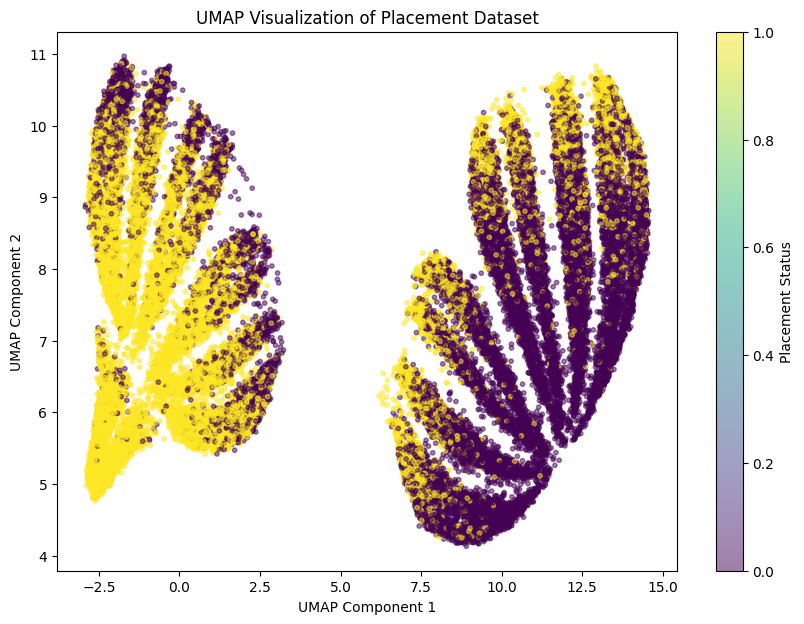

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import TruncatedSVD

import umap.umap_ as umap


# ==========================================
# 1. LOAD DATASET
# ==========================================

df = pd.read_csv("/content/placement_predict_50k_adjusted (1).csv")

print("Dataset shape:", df.shape)


# ==========================================
# 2. REMOVE TARGET AND ANOMALY COLUMNS
# ==========================================

X = df.drop(
    columns=["PlacementStatus", "IsAnomaly"],
    errors="ignore"
)


# ==========================================
# 3. IDENTIFY COLUMN TYPES
# ==========================================

categorical_cols = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numerical_cols = X.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

print("Numerical columns:", numerical_cols)
print("Categorical columns:", categorical_cols)


# ==========================================
# 4. CHECK MISSING VALUES
# ==========================================

print("\nMissing values:")
print(X.isnull().sum())


# ==========================================
# 5. NUMERICAL PIPELINE
# ==========================================

numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)


# ==========================================
# 6. CATEGORICAL PIPELINE
# ==========================================

categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=True
            )
        )
    ]
)


# ==========================================
# 7. COMBINE PREPROCESSING
# ==========================================

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_pipeline,
            numerical_cols
        ),
        (
            "cat",
            categorical_pipeline,
            categorical_cols
        )
    ]
)


# ==========================================
# 8. PREPROCESS DATA
# ==========================================

X_processed = preprocessor.fit_transform(X)

print("\nProcessed shape:", X_processed.shape)


# ==========================================
# 9. REDUCE FEATURES USING SVD
# ==========================================

svd = TruncatedSVD(
    n_components=30,
    random_state=42
)

X_reduced = svd.fit_transform(X_processed)

print("SVD shape:", X_reduced.shape)


# ==========================================
# 10. APPLY UMAP
# ==========================================

print("\nRunning UMAP...")

reducer = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric="euclidean",
    random_state=42
)

X_umap = reducer.fit_transform(X_reduced)

print("UMAP completed successfully!")
print("UMAP shape:", X_umap.shape)


# ==========================================
# 11. CONVERT PLACEMENT STATUS TO NUMBERS
# ==========================================

y_numeric = pd.factorize(
    df["PlacementStatus"]
)[0]


# ==========================================
# 12. VISUALIZATION
# ==========================================

plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    X_umap[:, 0],
    X_umap[:, 1],
    c=y_numeric,
    alpha=0.5,
    s=10
)

plt.xlabel("UMAP Component 1")
plt.ylabel("UMAP Component 2")

plt.title(
    "UMAP Visualization of Placement Dataset"
)

plt.colorbar(
    scatter,
    label="Placement Status"
)

plt.show()